
Gefundene Messblöcke: 1


        BLOCK 0
----- Abtastraten-Analyse -----
Anzahl Punkte:            240
Mittlerer Abstand:        332.99 µs
Reale Abtastrate:         3003.08 Hz
Blockdauer:               0.0796 s

----- Spektrale Merkmale -----
Amplitude   10 Hz:     0.001102
Amplitude   20 Hz:     0.000976
Amplitude   30 Hz:     0.000976
Amplitude   40 Hz:     0.045614
Amplitude   50 Hz:     0.104667


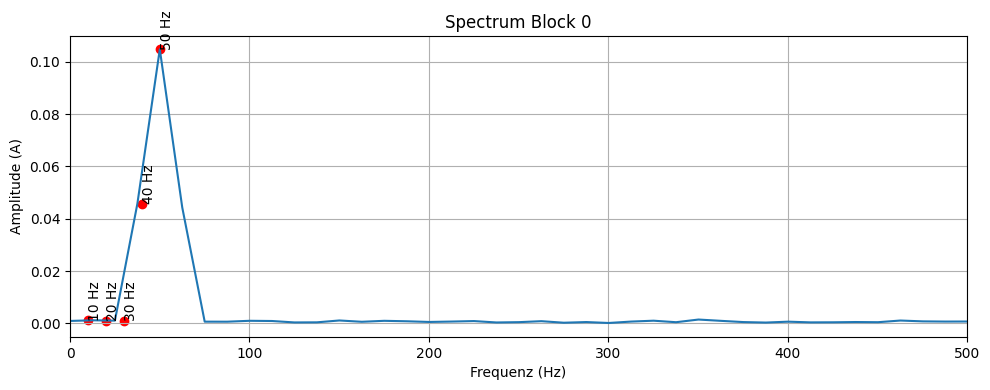

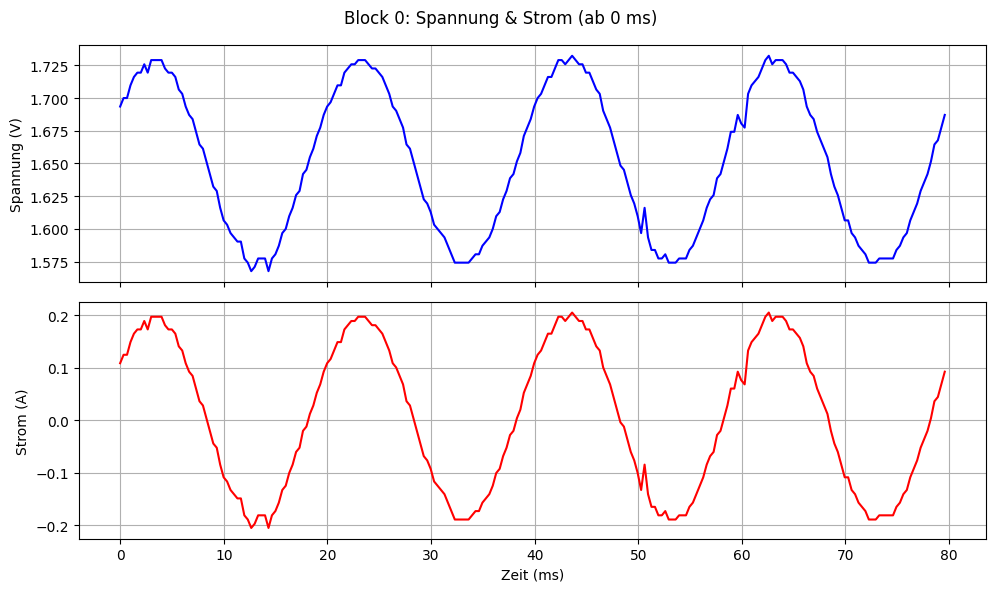


----- Zeitbereich-Merkmale -----
I_rms (Gesamt):           0.137815 A
I_max:                    0.205600 A
P ≈ I_rms * 220 V:        30.319 W

Feature-Vektor:
[0.13781513342155136, 0.2056, 0.00110209026255495, 0.0009763796596372377, 0.0009763796596372377, 0.04561446697363059, 0.10466728468989525]


===== Alle Feature-Vektoren =====
Block 0: [0.13781513342155136, 0.2056, 0.00110209026255495, 0.0009763796596372377, 0.0009763796596372377, 0.04561446697363059, 0.10466728468989525]


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === 1️⃣ Datei einlesen ===
filename = "ventelator.txt"

df = pd.read_csv(
    filename,
    sep=r"\s+",
    header=None,
    names=["time_us", "voltage_V", "current_A"]
)

# Zeit in Sekunden
df["time_s"] = df["time_us"] * 1e-6

# === 2️⃣ Zeit-Sprünge erkennen (mehrere Messblöcke!) ===
dt = df["time_us"].diff()
threshold = 2 * dt.median()              # robust
df["block"] = (dt > threshold).cumsum()

n_blocks = df["block"].max() + 1
print(f"\nGefundene Messblöcke: {n_blocks}\n")

# Für Ergebnisse
all_features = []

# =====================================
# === 3️⃣ Verarbeitung JE BLOCK ========
# =====================================
for blk, d in df.groupby("block"):
    print(f"\n===============================")
    print(f"        BLOCK {blk}")
    print(f"===============================")

    # Zeit normieren (Start bei 0)
    time_s = d["time_s"].to_numpy()
    time_s = time_s - time_s[0]

    # reale Abtastrate
    dt_s = np.diff(time_s)
    mean_dt_s = dt_s.mean()
    fs_real = 1.0 / mean_dt_s

    print("----- Abtastraten-Analyse -----")
    print(f"Anzahl Punkte:            {len(d)}")
    print(f"Mittlerer Abstand:        {mean_dt_s*1e6:.2f} µs")
    print(f"Reale Abtastrate:         {fs_real:.2f} Hz")
    print(f"Blockdauer:               {time_s[-1]:.4f} s")

    # === Stromsignal ===
    I = d["current_A"].to_numpy()
    I_ac = I - I.mean()

    # Fenster
    N = len(I_ac)
    window = np.hamming(N)
    I_win = I_ac *window

    # === FFT ===
    freqs = np.fft.rfftfreq(N, d=mean_dt_s)
    I_fft = np.fft.rfft(I_win)
    mag = np.abs(I_fft) * 2.0 / N   # einfache Normierung

    # Frequenzen, die du auswerten willst
    freq_targets = [10,20, 30, 40, 50]
    amps = []

    print("\n----- Spektrale Merkmale -----")
    for f in freq_targets:
        idx = np.argmin(np.abs(freqs - f))
        amps.append(mag[idx])
        print(f"Amplitude {f:4.0f} Hz:     {mag[idx]:.6f}")

    # === Spektrum plotten ===
    plt.figure(figsize=(10, 4))
    plt.plot(freqs, mag, label=f"Block {blk}")
    for f, a in zip(freq_targets, amps):
        plt.scatter(f, a, color="red")
        plt.text(f, a, f"{f} Hz", rotation=90, va="bottom")
    plt.xlim(0, 500)
    plt.grid(True)
    plt.title(f"Spectrum Block {blk}")
    plt.xlabel("Frequenz (Hz)")
    plt.ylabel("Amplitude (A)")
    plt.tight_layout()
    plt.show()

    # === Zeitbereichsplots ===
    time_ms = time_s * 1000

    fig, (axV, axI) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    axV.plot(time_ms, d["voltage_V"], color="blue")
    axV.set_ylabel("Spannung (V)")
    axV.grid(True)

    axI.plot(time_ms, d["current_A"], color="red")
    axI.set_ylabel("Strom (A)")
    axI.set_xlabel("Zeit (ms)")
    axI.grid(True)

    plt.suptitle(f"Block {blk}: Spannung & Strom (ab 0 ms)")
    plt.tight_layout()
    plt.show()

    # === RMS/Max/Leistung ===
    I_rms = np.sqrt(np.mean(I**2))
    I_max = np.max(np.abs(I))
    U_nom = 220.0
    P_rms = I_rms * U_nom

    print("\n----- Zeitbereich-Merkmale -----")
    print(f"I_rms (Gesamt):           {I_rms:.6f} A")
    print(f"I_max:                    {I_max:.6f} A")
    print(f"P ≈ I_rms * 220 V:        {P_rms:.3f} W")

    # Feature-Vektor
    feature_vec = [I_rms, I_max] + amps
    all_features.append(feature_vec)

    print("\nFeature-Vektor:")
    print(feature_vec)

# ================================================
# === 4️⃣ Zusammenfassung aller Blöcke ===========
# ================================================

print("\n\n===== Alle Feature-Vektoren =====")
for i, fv in enumerate(all_features):
    print(f"Block {i}: {fv}")



Gefundene Messblöcke: 6


        BLOCK 0
----- Abtastraten-Analyse -----
Anzahl Punkte:            38
Mittlerer Abstand:        333.03 µs
Reale Abtastrate:         3002.76 Hz
Blockdauer:               0.0123 s

----- Spektrale Merkmale -----
Amplitude   50 Hz:     0.044549
Amplitude  100 Hz:     0.044549
Amplitude  150 Hz:     0.072409
Amplitude  200 Hz:     0.057537
Amplitude  250 Hz:     0.057537


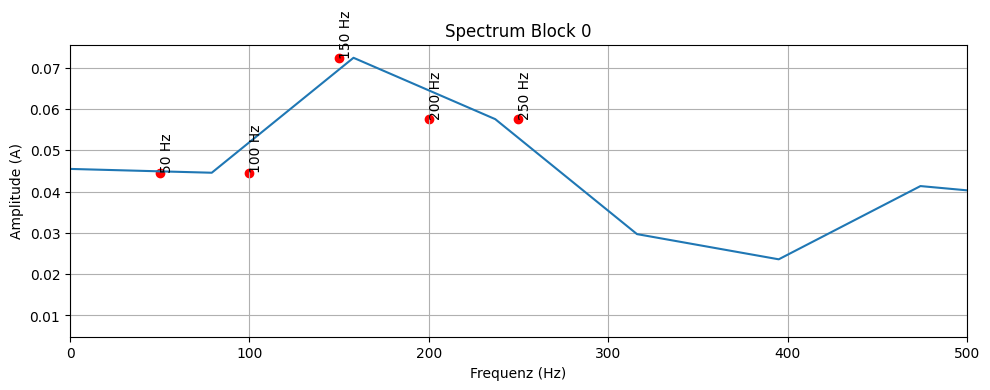

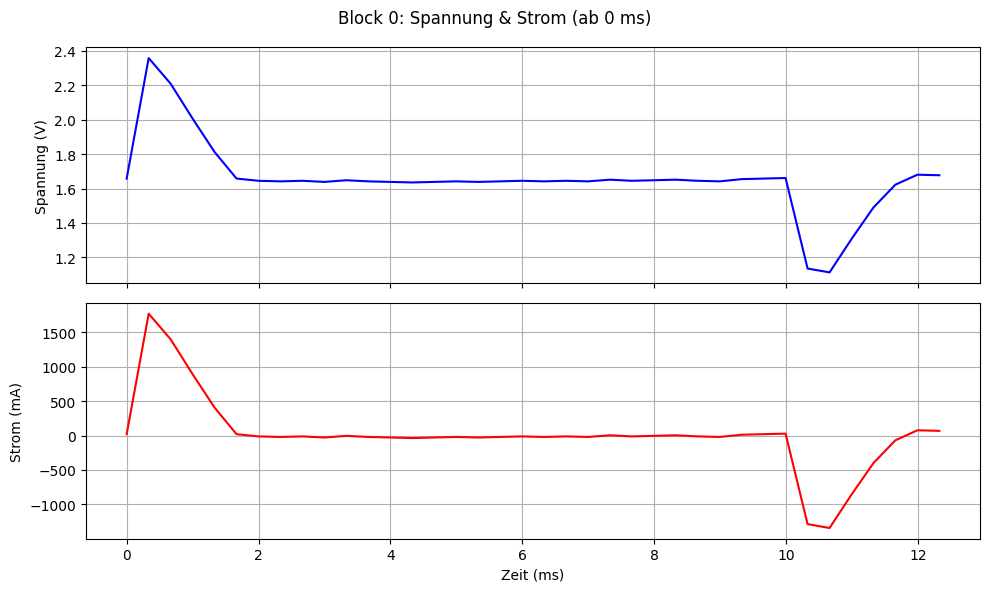


----- Zeitbereich-Merkmale -----
I_rms (Gesamt):           0.523940 A
I_max:                    1.770200 A
P ≈ I_rms * 220 V:        115.267 W

Feature-Vektor:
[0.5239404654307486, 1.7702, 0.044548765721409395, 0.044548765721409395, 0.07240881866544792, 0.05753711505969425, 0.05753711505969425]

        BLOCK 1
----- Abtastraten-Analyse -----
Anzahl Punkte:            240
Mittlerer Abstand:        333.00 µs
Reale Abtastrate:         3003.04 Hz
Blockdauer:               0.0796 s

----- Spektrale Merkmale -----
Amplitude   50 Hz:     0.172060
Amplitude  100 Hz:     0.002750
Amplitude  150 Hz:     0.160302
Amplitude  200 Hz:     0.001612
Amplitude  250 Hz:     0.142445


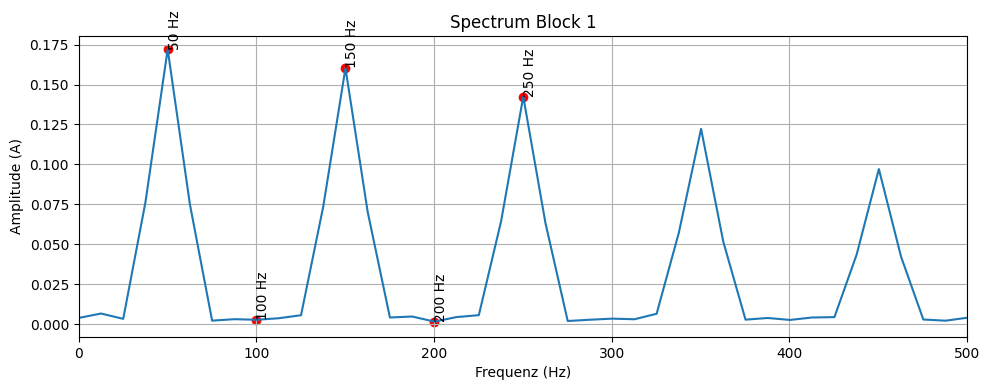

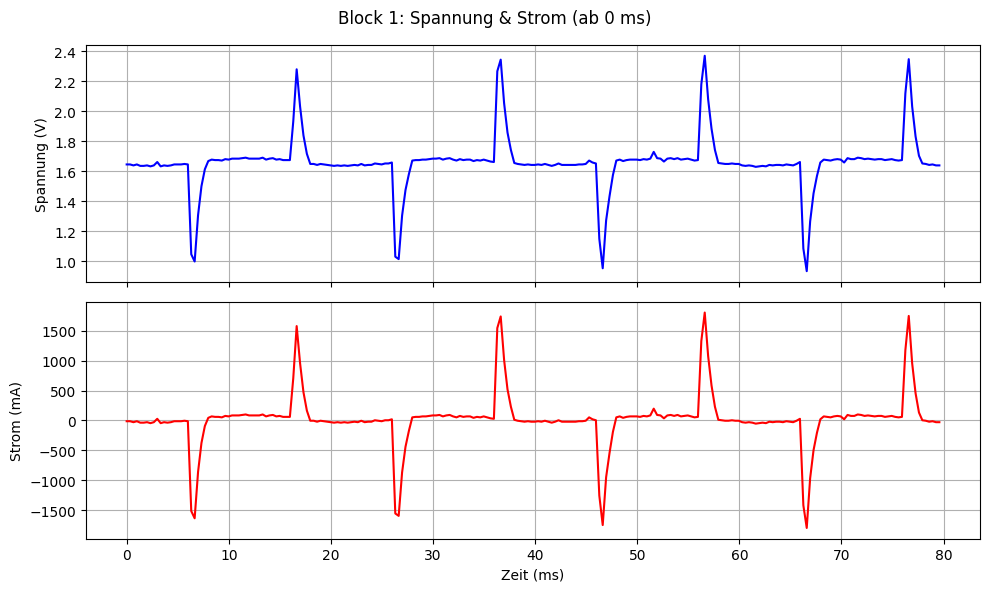


----- Zeitbereich-Merkmale -----
I_rms (Gesamt):           0.445743 A
I_max:                    1.802400 A
P ≈ I_rms * 220 V:        98.063 W

Feature-Vektor:
[0.4457429102539564, 1.8024, 0.17206041335910982, 0.00274999182112823, 0.16030155361842027, 0.0016118746615680995, 0.14244546393182603]

        BLOCK 2
----- Abtastraten-Analyse -----
Anzahl Punkte:            240
Mittlerer Abstand:        333.00 µs
Reale Abtastrate:         3003.04 Hz
Blockdauer:               0.0796 s

----- Spektrale Merkmale -----
Amplitude   50 Hz:     0.169498
Amplitude  100 Hz:     0.006171
Amplitude  150 Hz:     0.158734
Amplitude  200 Hz:     0.007534
Amplitude  250 Hz:     0.144139


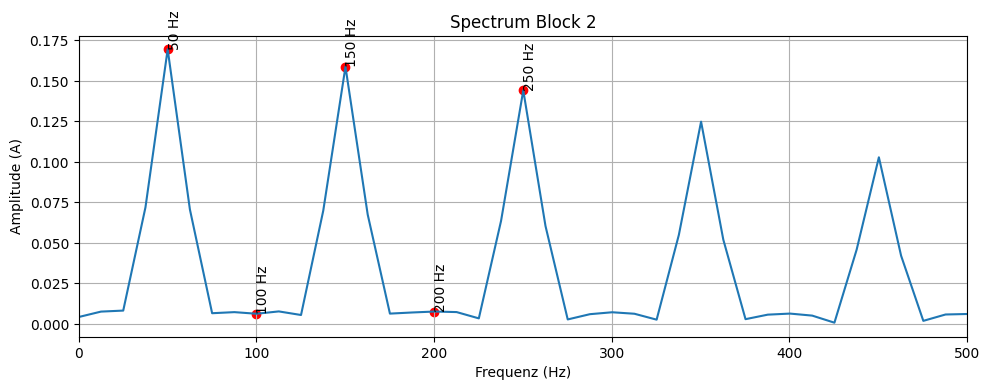

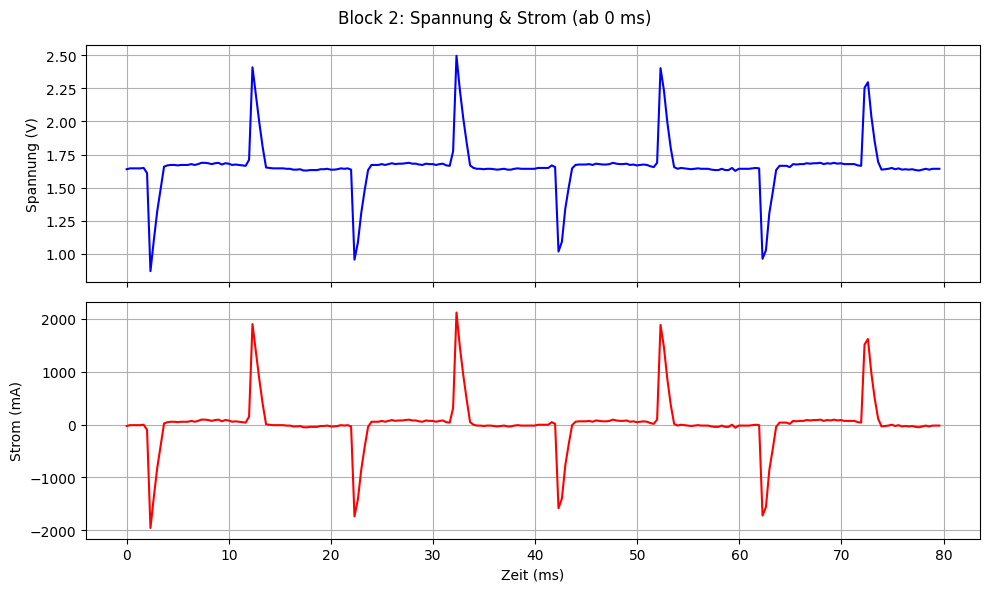


----- Zeitbereich-Merkmale -----
I_rms (Gesamt):           0.462929 A
I_max:                    2.116900 A
P ≈ I_rms * 220 V:        101.844 W

Feature-Vektor:
[0.46292946884487707, 2.1169, 0.1694975055962357, 0.006171091281943195, 0.1587336060960851, 0.007534279156778788, 0.14413905450028466]

        BLOCK 3
----- Abtastraten-Analyse -----
Anzahl Punkte:            240
Mittlerer Abstand:        333.00 µs
Reale Abtastrate:         3003.04 Hz
Blockdauer:               0.0796 s

----- Spektrale Merkmale -----
Amplitude   50 Hz:     0.183188
Amplitude  100 Hz:     0.001695
Amplitude  150 Hz:     0.172174
Amplitude  200 Hz:     0.002968
Amplitude  250 Hz:     0.154127


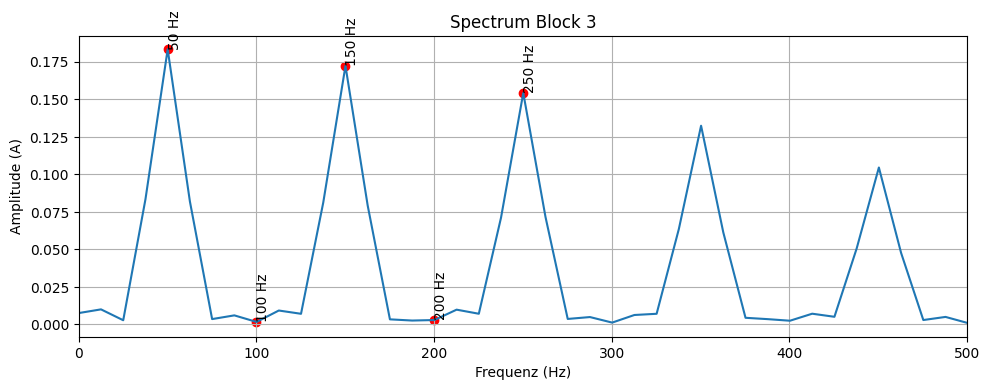

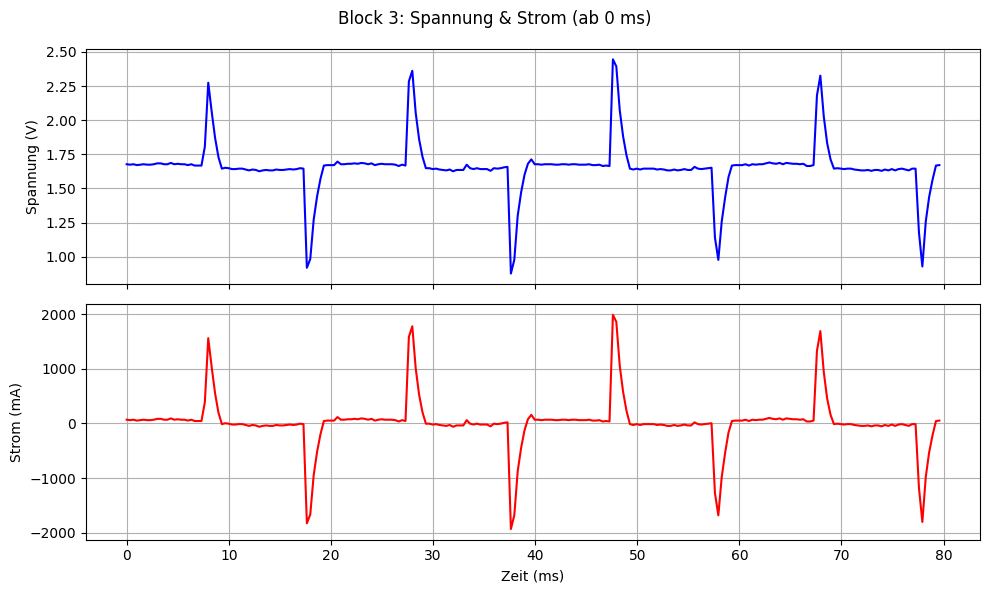


----- Zeitbereich-Merkmale -----
I_rms (Gesamt):           0.468795 A
I_max:                    1.987900 A
P ≈ I_rms * 220 V:        103.135 W

Feature-Vektor:
[0.46879542095495486, 1.9879, 0.18318825621250662, 0.0016952185669954188, 0.17217354552740638, 0.0029675793678650034, 0.1541269425877873]

        BLOCK 4
----- Abtastraten-Analyse -----
Anzahl Punkte:            240
Mittlerer Abstand:        332.99 µs
Reale Abtastrate:         3003.08 Hz
Blockdauer:               0.0796 s

----- Spektrale Merkmale -----
Amplitude   50 Hz:     0.141879
Amplitude  100 Hz:     0.002240
Amplitude  150 Hz:     0.132585
Amplitude  200 Hz:     0.003173
Amplitude  250 Hz:     0.120796


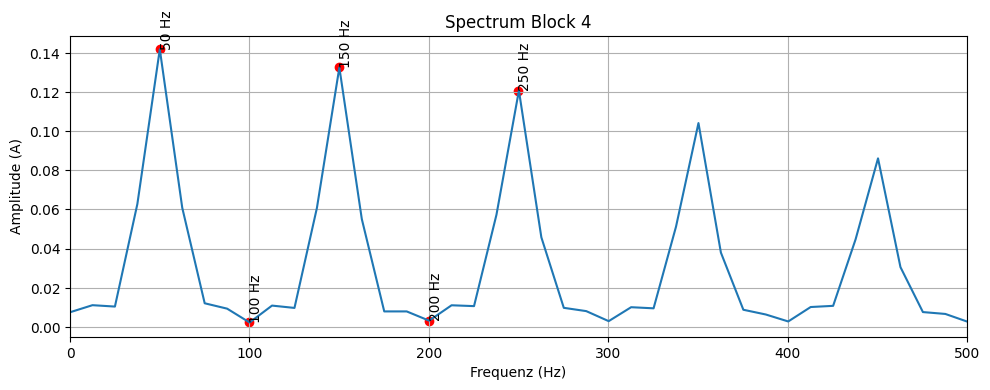

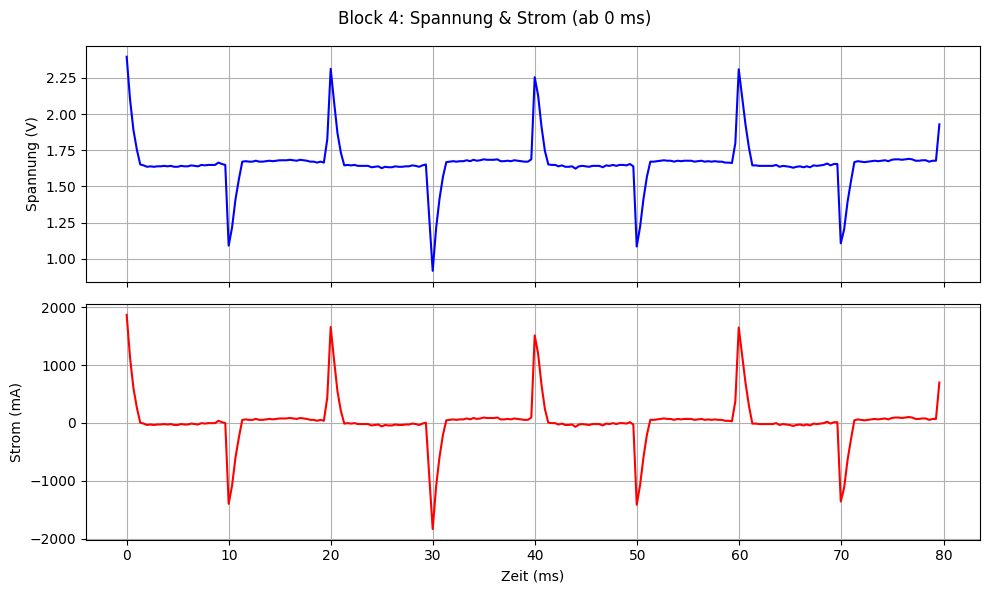


----- Zeitbereich-Merkmale -----
I_rms (Gesamt):           0.388113 A
I_max:                    1.866900 A
P ≈ I_rms * 220 V:        85.385 W

Feature-Vektor:
[0.38811318001325334, 1.8669, 0.14187910771440201, 0.002240404983864576, 0.13258474780125937, 0.0031728905901209402, 0.1207956748563121]

        BLOCK 5
----- Abtastraten-Analyse -----
Anzahl Punkte:            17
Mittlerer Abstand:        332.87 µs
Reale Abtastrate:         3004.13 Hz
Blockdauer:               0.0053 s

----- Spektrale Merkmale -----
Amplitude   50 Hz:     0.196603
Amplitude  100 Hz:     0.309497
Amplitude  150 Hz:     0.309497
Amplitude  200 Hz:     0.309497
Amplitude  250 Hz:     0.309497


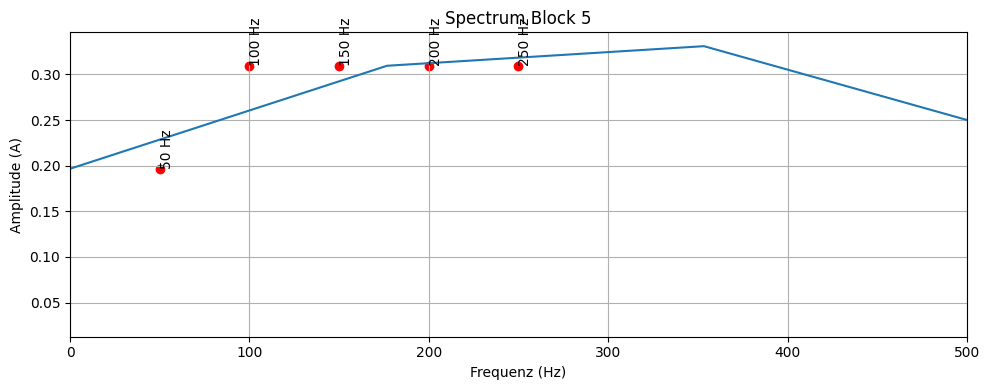

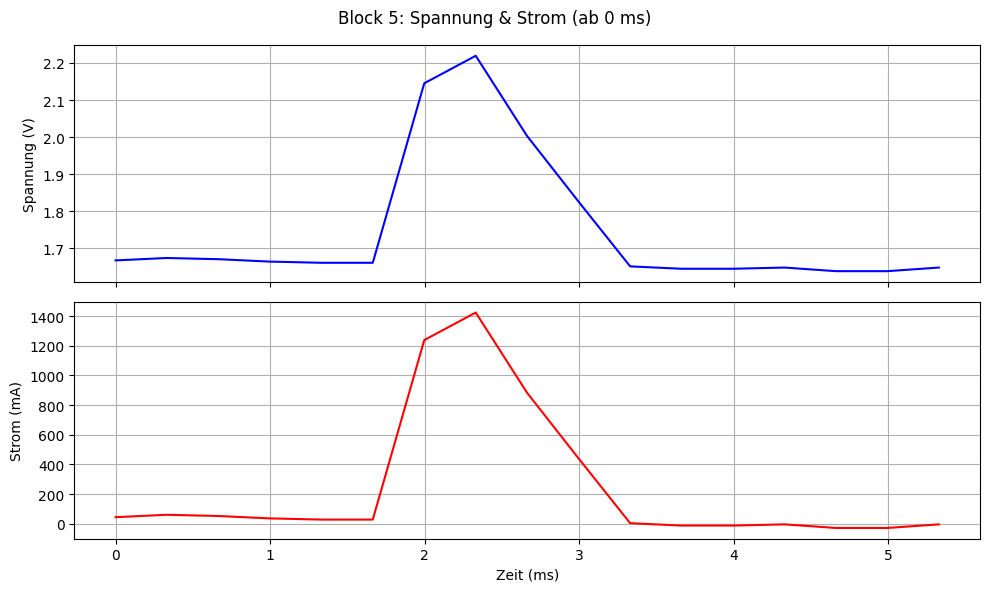


----- Zeitbereich-Merkmale -----
I_rms (Gesamt):           0.517045 A
I_max:                    1.423400 A
P ≈ I_rms * 220 V:        113.750 W

Feature-Vektor:
[0.5170451493540851, 1.4234, 0.1966026361622321, 0.3094966277065543, 0.3094966277065543, 0.3094966277065543, 0.3094966277065543]


===== Alle Feature-Vektoren =====
Block 0: [0.5239404654307486, 1.7702, 0.044548765721409395, 0.044548765721409395, 0.07240881866544792, 0.05753711505969425, 0.05753711505969425]
Block 1: [0.4457429102539564, 1.8024, 0.17206041335910982, 0.00274999182112823, 0.16030155361842027, 0.0016118746615680995, 0.14244546393182603]
Block 2: [0.46292946884487707, 2.1169, 0.1694975055962357, 0.006171091281943195, 0.1587336060960851, 0.007534279156778788, 0.14413905450028466]
Block 3: [0.46879542095495486, 1.9879, 0.18318825621250662, 0.0016952185669954188, 0.17217354552740638, 0.0029675793678650034, 0.1541269425877873]
Block 4: [0.38811318001325334, 1.8669, 0.14187910771440201, 0.002240404983864576, 0.132584747

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === 1️⃣ Datei einlesen ===
filename = "lpt_netzteil1.txt"

df = pd.read_csv(
    filename,
    sep=r"\s+",
    header=None,
    names=["time_us", "voltage_V", "current_A"]
)

# Zeit in Sekunden
df["time_s"] = df["time_us"] * 1e-6

# === 2️⃣ Zeit-Sprünge erkennen (mehrere Messblöcke!) ===
dt = df["time_us"].diff()
threshold = 2 * dt.median()              # robust
df["block"] = (dt > threshold).cumsum()

n_blocks = df["block"].max() + 1
print(f"\nGefundene Messblöcke: {n_blocks}\n")

# Für Ergebnisse
all_features = []

# =====================================
# === 3️⃣ Verarbeitung JE BLOCK ========
# =====================================
for blk, d in df.groupby("block"):
    print(f"\n===============================")
    print(f"        BLOCK {blk}")
    print(f"===============================")

    # Zeit normieren (Start bei 0)
    time_s = d["time_s"].to_numpy()
    time_s = time_s - time_s[0]

    # reale Abtastrate
    dt_s = np.diff(time_s)
    mean_dt_s = dt_s.mean()
    fs_real = 1.0 / mean_dt_s

    print("----- Abtastraten-Analyse -----")
    print(f"Anzahl Punkte:            {len(d)}")
    print(f"Mittlerer Abstand:        {mean_dt_s*1e6:.2f} µs")
    print(f"Reale Abtastrate:         {fs_real:.2f} Hz")
    print(f"Blockdauer:               {time_s[-1]:.4f} s")

    # === Stromsignal ===
    I = d["current_A"].to_numpy()
    I_ac = I - I.mean()

    # Fenster
    N = len(I_ac)
    window = np.hamming(N)
    I_win = I_ac * window

    # === FFT ===
    freqs = np.fft.rfftfreq(N, d=mean_dt_s)
    I_fft = np.fft.rfft(I_win)
    mag = np.abs(I_fft) * 2.0 / N   # einfache Normierung

    # Frequenzen, die du auswerten willst
    freq_targets = [50,100, 150, 200, 250]
    amps = []

    print("\n----- Spektrale Merkmale -----")
    for f in freq_targets:
        idx = np.argmin(np.abs(freqs - f))
        amps.append(mag[idx])
        print(f"Amplitude {f:4.0f} Hz:     {mag[idx]:.6f}")

    # === Spektrum plotten ===
    plt.figure(figsize=(10, 4))
    plt.plot(freqs, mag, label=f"Block {blk}")
    for f, a in zip(freq_targets, amps):
        plt.scatter(f, a, color="red")
        plt.text(f, a, f"{f} Hz", rotation=90, va="bottom")
    plt.xlim(0, 500)
    plt.grid(True)
    plt.title(f"Spectrum Block {blk}")
    plt.xlabel("Frequenz (Hz)")
    plt.ylabel("Amplitude (A)")
    plt.tight_layout()
    plt.show()

    # === Zeitbereichsplots ===
    time_ms = time_s * 1000

    fig, (axV, axI) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    axV.plot(time_ms, d["voltage_V"], color="blue")
    axV.set_ylabel("Spannung (V)")
    axV.grid(True)

    axI.plot(time_ms, d["current_A"]*1000, color="red")
    axI.set_ylabel("Strom (mA)")
    axI.set_xlabel("Zeit (ms)")
    axI.grid(True)

    plt.suptitle(f"Block {blk}: Spannung & Strom (ab 0 ms)")
    plt.tight_layout()
    plt.show()

    # === RMS/Max/Leistung ===
    I_rms = np.sqrt(np.mean(I**2))
    I_max = np.max(np.abs(I))
    U_nom = 220.0
    P_rms = I_rms * U_nom

    print("\n----- Zeitbereich-Merkmale -----")
    print(f"I_rms (Gesamt):           {I_rms:.6f} A")
    print(f"I_max:                    {I_max:.6f} A")
    print(f"P ≈ I_rms * 220 V:        {P_rms:.3f} W")

    # Feature-Vektor
    feature_vec = [I_rms, I_max] + amps
    all_features.append(feature_vec)

    print("\nFeature-Vektor:")
    print(feature_vec)

# ================================================
# === 4️⃣ Zusammenfassung aller Blöcke ===========
# ================================================

print("\n\n===== Alle Feature-Vektoren =====")
for i, fv in enumerate(all_features):
    print(f"Block {i}: {fv}")


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# === 1️⃣ Datei einlesen =========
# ===============================

filename = "lpt_netzteil1.txt"

df = pd.read_csv(
    filename,
    sep=r"\s+",
    header=None,
    names=["time_us", "voltage_V", "current_A"]
)

# Zeit in Sekunden
df["time_s"] = df["time_us"] * 1e-6

# =========================================
# === 2️⃣ Messblöcke anhand Zeitlücken =====
# =========================================

dt_us = df["time_us"].diff()
threshold = 2 * dt_us.median()
df["block"] = (dt_us > threshold).cumsum()

n_blocks = df["block"].max() + 1
print(f"\nGefundene Messblöcke: {n_blocks}\n")

# Ziel-Frequenzen
freq_targets = [50, 100, 150, 200, 250]

# Alle Features (über alle Blöcke)
all_feature_frames = []

# =========================================
# === 3️⃣ Verarbeitung JE BLOCK ============
# =========================================

for blk, d in df.groupby("block"):
    print(f"\n===============================")
    print(f"        BLOCK {blk}")
    print(f"===============================")

    # Zeit bei 0 starten
    time_s = d["time_s"].to_numpy()
    time_s = time_s - time_s[0]

    # Reale Abtastrate
    dt_s = np.diff(time_s)
    mean_dt_s = dt_s.mean()
    fs_real = 1.0 / mean_dt_s

    print(f"Reale Abtastrate: {fs_real:.2f} Hz")

    # ===============================
    # === Fensterparameter ==========
    # ===============================

    window_len_s = 0.020                 # 20 ms
    window_len_N = int(window_len_s * fs_real)
    hop_N = window_len_N // 2             # 50 % Überlappung

    print(f"Fenstergröße: {window_len_N} Samples")

    I = d["current_A"].to_numpy()

    feature_vectors = []
    time_stamps = []

    # ===============================
    # === 20-ms-Fenster-Schleife ====
    # ===============================

    for start in range(0, len(I) - window_len_N, hop_N):
        stop = start + window_len_N

        I_seg = I[start:stop]
        t_seg = time_s[start:stop]

        # === Zeitbereichsfeatures ===
        I_rms = np.sqrt(np.mean(I_seg ** 2))
        I_max = np.max(np.abs(I_seg))

        # === FFT-Vorbereitung ===
        I_ac = I_seg - I_seg.mean()
        window = np.hamming(window_len_N)
        I_win = I_ac * window

        # === FFT ===
        fft_vals = np.fft.rfft(I_win)
        freqs = np.fft.rfftfreq(window_len_N, d=mean_dt_s)
        mag = np.abs(fft_vals) * 2.0 / window_len_N

        # === Spektrale Features ===
        amps = []
        for f in freq_targets:
            idx = np.argmin(np.abs(freqs - f))
            amps.append(mag[idx])

        # === Feature-Vektor ===
        feature_vec = [I_rms, I_max] + amps

        feature_vectors.append(feature_vec)
        time_stamps.append(t_seg[0])

    # ===============================
    # === In DataFrame speichern ====
    # ===============================

    columns = (
        ["I_rms_A", "I_max_A"] +
        [f"Amp_{f}Hz" for f in freq_targets]
    )

    df_feat = pd.DataFrame(feature_vectors, columns=columns)
    df_feat["time_s"] = time_stamps
    df_feat["block"] = blk

    all_feature_frames.append(df_feat)

# =========================================
# === 4️⃣ Alle Blöcke zusammenführen ======
# =========================================

df_features_all = pd.concat(all_feature_frames, ignore_index=True)

print("\n===== FEATURE-MATRIX =====")
print(df_features_all.head())
print("\nShape:", df_features_all.shape)

# Optional: speichern
df_features_all.to_csv("features_20ms.csv", index=False)



Gefundene Messblöcke: 6


        BLOCK 0
Reale Abtastrate: 3002.76 Hz
Fenstergröße: 60 Samples

        BLOCK 1
Reale Abtastrate: 3003.04 Hz
Fenstergröße: 60 Samples

        BLOCK 2
Reale Abtastrate: 3003.04 Hz
Fenstergröße: 60 Samples

        BLOCK 3
Reale Abtastrate: 3003.04 Hz
Fenstergröße: 60 Samples

        BLOCK 4
Reale Abtastrate: 3003.08 Hz
Fenstergröße: 60 Samples

        BLOCK 5
Reale Abtastrate: 3004.13 Hz
Fenstergröße: 60 Samples

===== FEATURE-MATRIX =====
    I_rms_A  I_max_A  Amp_50Hz  Amp_100Hz  Amp_150Hz  Amp_200Hz  Amp_250Hz  \
0  0.411302   1.6331  0.158006   0.099708   0.145119   0.079196   0.130481   
1  0.412932   1.5927  0.148665   0.067297   0.136710   0.052867   0.120767   
2  0.461871   1.7379  0.169126   0.089079   0.162778   0.073005   0.141081   
3  0.460517   1.7460  0.171464   0.093759   0.162818   0.079373   0.145834   
4  0.458005   1.8024  0.175651   0.094316   0.159887   0.072716   0.143008   

     time_s  block  
0  0.000000      1  
1  0.0099

C:\Users\taleb\AppData\Local\Temp\ipykernel_13856\2887094176.py:128: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_features_all = pd.concat(all_feature_frames, ignore_index=True)


Median dt_us (positiv): 333.000 µs
Sprung-Threshold:       666.000 µs  (JUMP_FACTOR=2.0)
Gefundene Blöcke:       4


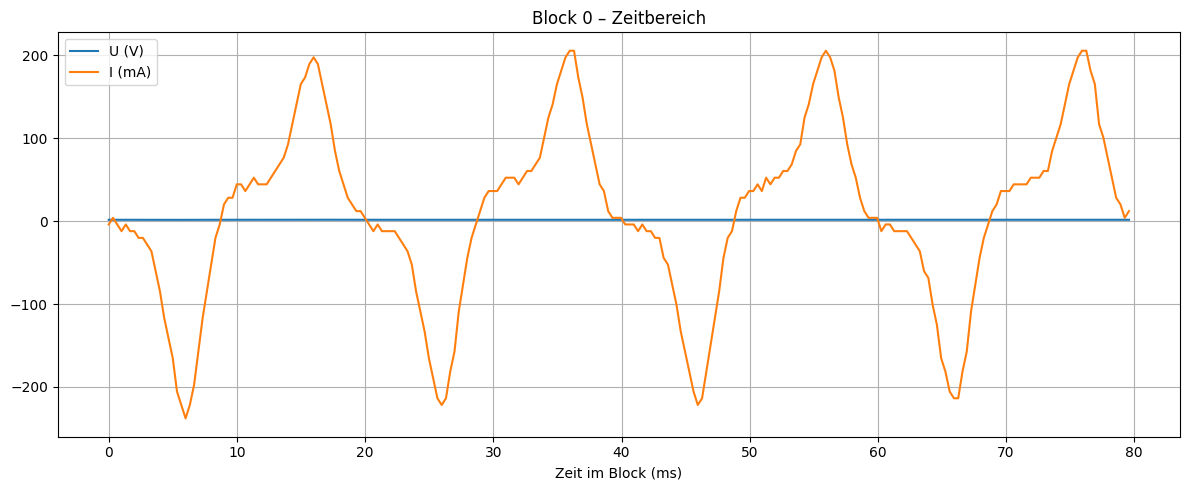

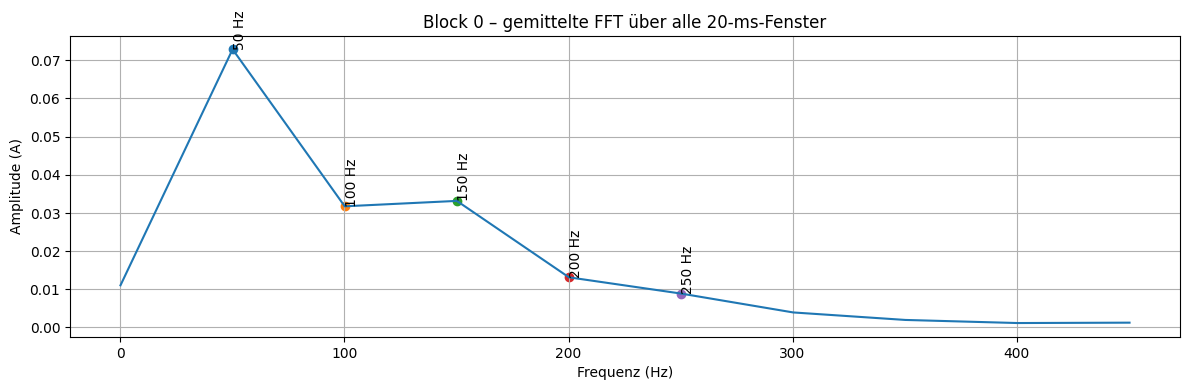

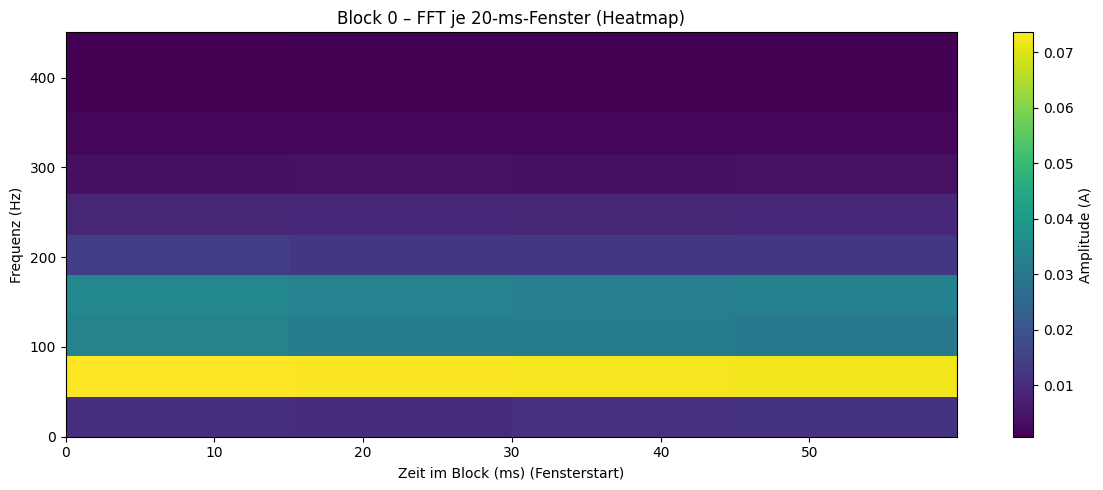

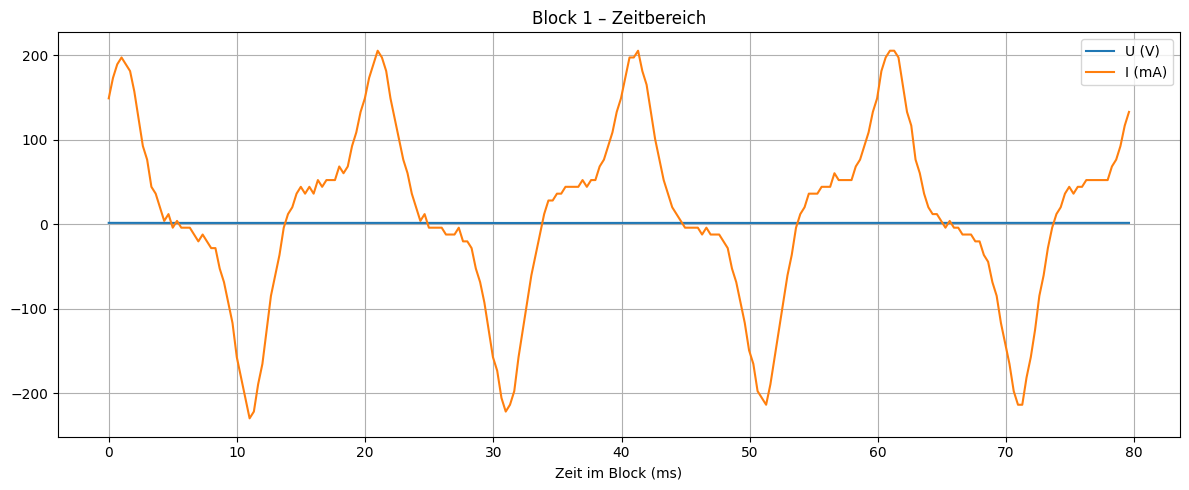

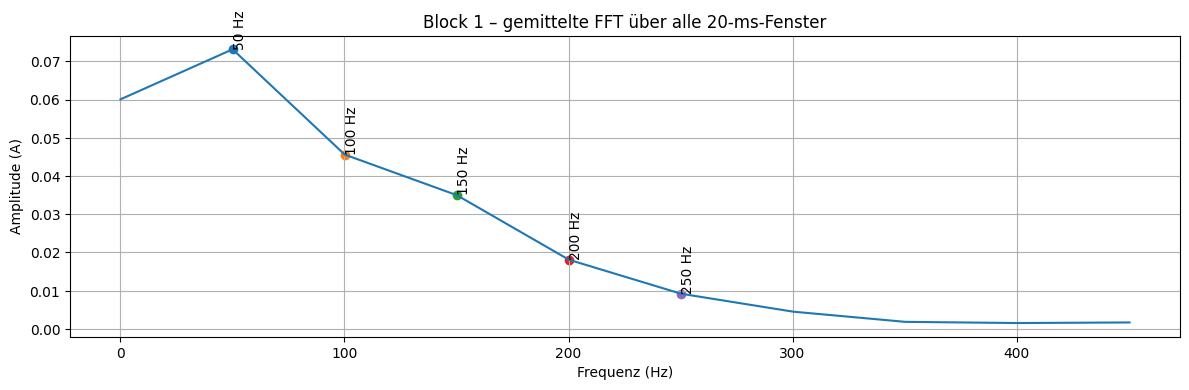

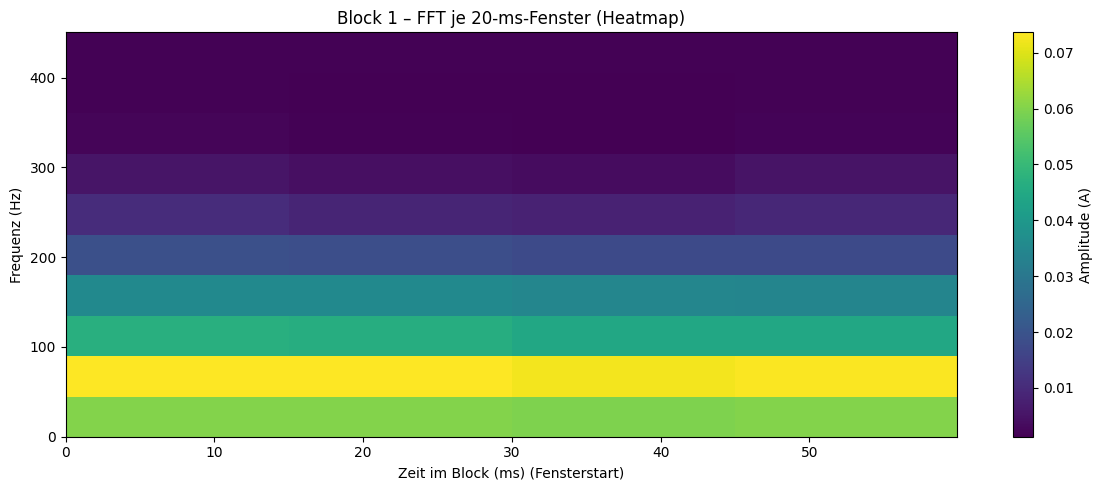

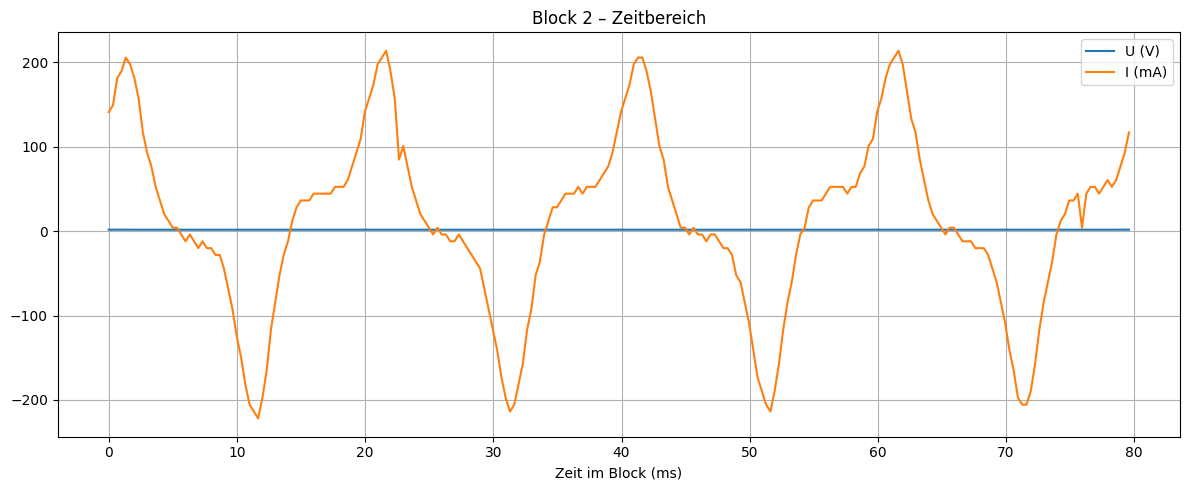

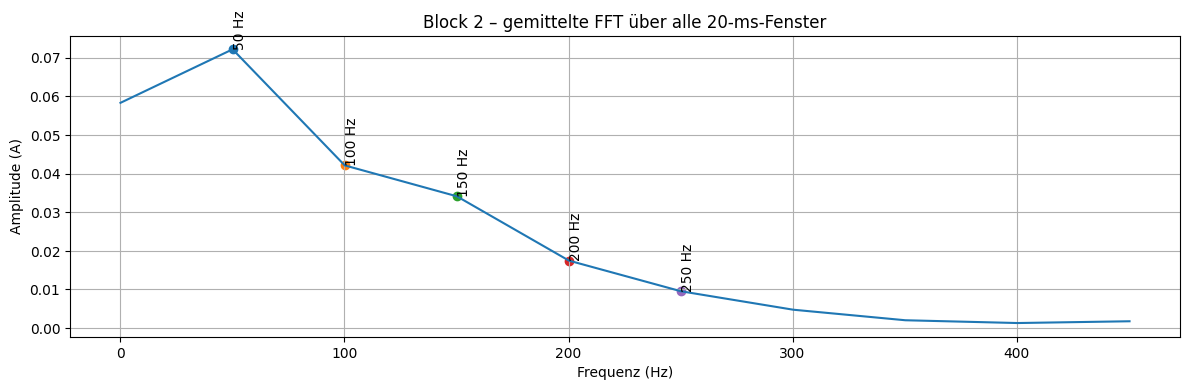

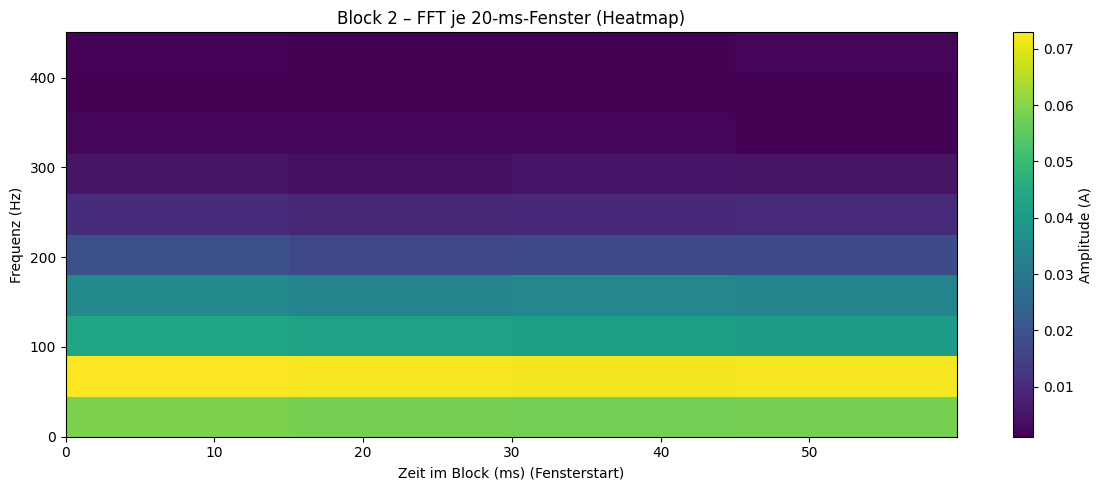

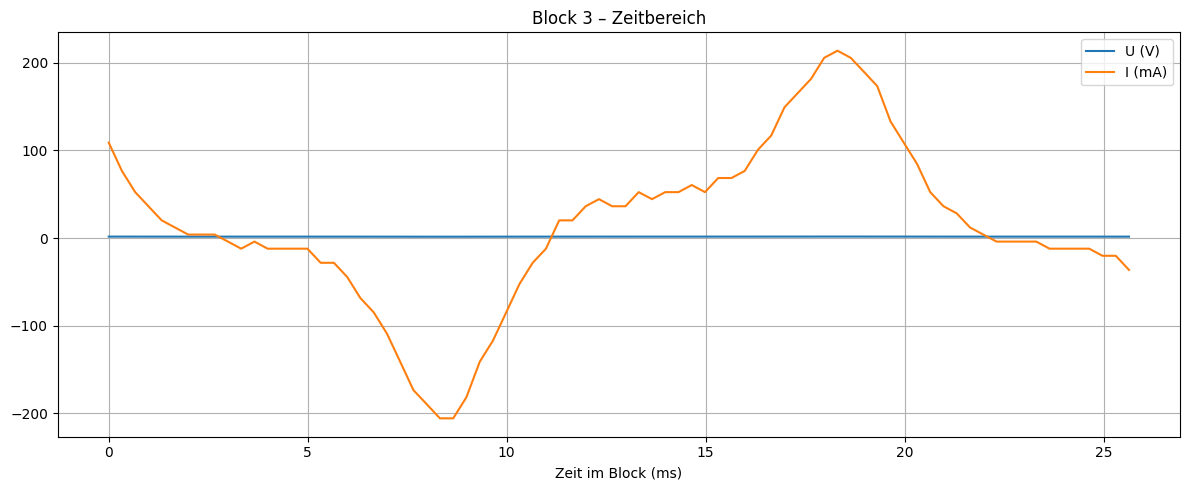

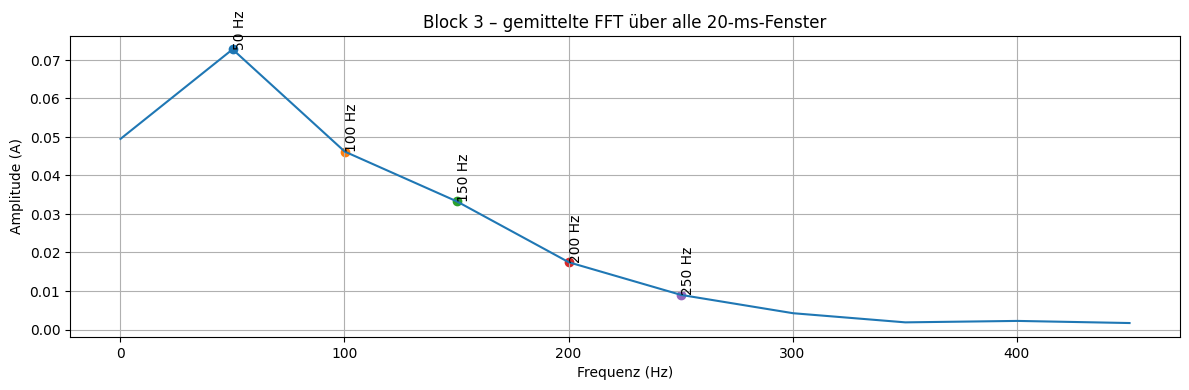

C:\Users\taleb\AppData\Local\Temp\ipykernel_13856\3478385446.py:174: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.imshow(


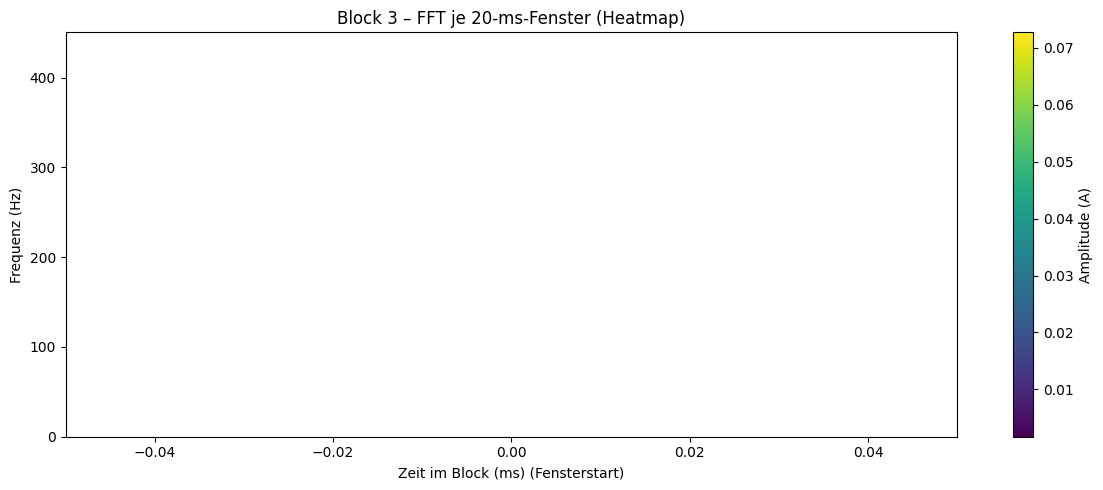


✅ Gespeichert: features_20ms.csv
   block  window_idx      t0_s   I_rms_A  I_max_A  Amp_50Hz  Amp_100Hz  \
0      0           0  0.000000  0.106513   0.2379  0.073616   0.033413   
1      0           1  0.019979  0.106016   0.2218  0.073061   0.031764   
2      0           2  0.039958  0.105106   0.2218  0.072675   0.031264   
3      0           3  0.059939  0.105349   0.2137  0.072156   0.030320   
4      1           0  0.000000  0.104316   0.2298  0.073653   0.046933   
5      1           1  0.019979  0.104245   0.2218  0.073410   0.046227   
6      1           2  0.039958  0.103532   0.2137  0.072518   0.044736   
7      1           3  0.059938  0.104637   0.2137  0.073119   0.044588   
8      2           0  0.000000  0.104337   0.2218  0.072905   0.043556   
9      2           1  0.019978  0.103404   0.2137  0.071899   0.042429   

   Amp_150Hz  Amp_200Hz  Amp_250Hz  
0   0.034633   0.014347   0.008635  
1   0.033036   0.012543   0.008946  
2   0.032096   0.012639   0.008730  
3  

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Einstellungen
# =========================
filename = "lötStation_test1.txt"

PERIOD_S = 0.020  # 20 ms = 1 Netzperiode (50 Hz)
FREQ_TARGETS = [50, 100, 150, 200, 250]

# Sprungdetektion in time_us:
JUMP_FACTOR = 2.0   # threshold = JUMP_FACTOR * median(dt_us_pos)
FREQ_PLOT_MAX = 500 # für FFT-Plots/Heatmap

# Speichern
OUT_CSV = "features_20ms.csv"


# =========================
# Hilfsfunktionen
# =========================
def detect_blocks(df: pd.DataFrame, jump_factor: float = 2.0) -> pd.Series:
    """Erzeugt Block-IDs anhand Zeit-Sprüngen oder nicht-monotoner Zeit."""
    dt_us = df["time_us"].diff()
    dt_pos = dt_us[dt_us > 0]
    if len(dt_pos) == 0:
        raise ValueError("Keine positiven Zeitabstände in time_us gefunden. Prüfe Datei/Format.")

    med = float(dt_pos.median())
    thr = jump_factor * med

    # Neuer Block bei Sprung oder nicht-monoton (<=0)
    new_block = (dt_us > thr) | (dt_us <= 0)
    return new_block.cumsum(), med, thr


def window_features_for_block(d: pd.DataFrame, period_s: float, freq_targets):
    """
    Zerlegt Block in nicht-überlappende 20ms-Fenster und berechnet Features pro Fenster:
    I_rms, I_max, Amp@Targets (aus FFT).
    Gibt:
      - df_feat: Feature-DataFrame pro Fenster
      - freqs: Frequenzachse der FFT (für Plot)
      - mags: 2D array [n_windows, n_freqbins] (für Heatmap/Mean FFT)
      - t0s: Startzeiten der Fenster (s, relativ zum Block)
    """
    t = d["time_s"].to_numpy(dtype=float)
    I = d["current_A"].to_numpy(dtype=float)

    # Blockzeit bei 0 starten
    t = t - t[0]

    # robustes dt (Median), nur positive Abstände
    dt_vec = np.diff(t)
    dt_vec = dt_vec[dt_vec > 0]
    if len(dt_vec) == 0:
        return None, None, None, None

    dt = float(np.median(dt_vec))
    fs = 1.0 / dt

    # Samples pro 20ms
    N = int(round(period_s * fs))
    N = max(N, 8)  # Schutz

    if len(I) < N:
        return None, None, None, None

    hop = N  # NICHT überlappend: jede Periode = 20 ms

    window = np.hamming(N)
    freqs = np.fft.rfftfreq(N, d=dt)

    rows = []
    mags = []
    t0s = []

    # Fensterweise
    w_idx = 0
    for start in range(0, len(I) - N + 1, hop):
        stop = start + N
        seg = I[start:stop]

        # Zeitmarke: Fensterstart
        t0 = float(t[start])
        t0s.append(t0)

        # Zeitbereichsfeatures
        I_rms = float(np.sqrt(np.mean(seg ** 2)))
        I_max = float(np.max(np.abs(seg)))

        # FFT-Features (DC entfernen + Fenster)
        seg_ac = seg - np.mean(seg)
        X = np.fft.rfft(seg_ac * window)
        mag = np.abs(X) * 2.0 / N  # einfache einseitige Normierung

        mags.append(mag)

        # Target-Amplituden
        amps = []
        for f in freq_targets:
            idx = int(np.argmin(np.abs(freqs - f)))
            amps.append(float(mag[idx]))

        rows.append([w_idx, t0, I_rms, I_max] + amps)
        w_idx += 1

    cols = ["window_idx", "t0_s", "I_rms_A", "I_max_A"] + [f"Amp_{f}Hz" for f in freq_targets]
    df_feat = pd.DataFrame(rows, columns=cols)

    mags = np.vstack(mags)  # [n_windows, n_freqbins]
    t0s = np.array(t0s, dtype=float)

    return df_feat, freqs, mags, t0s


def plot_block_time(d: pd.DataFrame, blk: int):
    t = d["time_s"].to_numpy(dtype=float)
    t = t - t[0]
    U = d["voltage_V"].to_numpy(dtype=float)
    I = d["current_A"].to_numpy(dtype=float)

    plt.figure(figsize=(12, 5))
    plt.plot(t * 1000, U, label="U (V)")
    plt.plot(t * 1000, I * 1000, label="I (mA)")
    plt.xlabel("Zeit im Block (ms)")
    plt.title(f"Block {blk} – Zeitbereich")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_block_fft_mean(blk: int, freqs: np.ndarray, mags: np.ndarray, freq_targets, fmax=500):
    fft_mean = mags.mean(axis=0)

    # Frequenzlimit
    mask = freqs <= fmax
    f_plot = freqs[mask]
    m_plot = fft_mean[mask]

    plt.figure(figsize=(12, 4))
    plt.plot(f_plot, m_plot)

    for f in freq_targets:
        idx = int(np.argmin(np.abs(freqs - f)))
        if freqs[idx] <= fmax:
            plt.scatter(freqs[idx], fft_mean[idx])
            plt.text(freqs[idx], fft_mean[idx], f"{f} Hz", rotation=90, va="bottom")

    plt.xlabel("Frequenz (Hz)")
    plt.ylabel("Amplitude (A)")
    plt.title(f"Block {blk} – gemittelte FFT über alle 20-ms-Fenster")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_block_spectrogram(blk: int, freqs: np.ndarray, mags: np.ndarray, t0s: np.ndarray, fmax=500):
    """
    Visualisiert die FFT JE 20ms-Fenster als Heatmap.
    x = Zeit (ms), y = Frequenz (Hz), Farbe = Amplitude.
    """
    mask = freqs <= fmax
    f_plot = freqs[mask]
    M = mags[:, mask]  # [n_windows, n_freqbins<=fmax]

    # Achsen: Zeit pro Fenster (Fensterstart) in ms
    x = t0s * 1000

    plt.figure(figsize=(12, 5))
    plt.imshow(
        M.T,
        aspect="auto",
        origin="lower",
        extent=[x.min(), x.max(), f_plot.min(), f_plot.max()]
    )
    plt.xlabel("Zeit im Block (ms) (Fensterstart)")
    plt.ylabel("Frequenz (Hz)")
    plt.title(f"Block {blk} – FFT je 20-ms-Fenster (Heatmap)")
    plt.colorbar(label="Amplitude (A)")
    plt.tight_layout()
    plt.show()


# =========================
# Hauptprogramm
# =========================
df = pd.read_csv(
    filename,
    sep=r"\s+",
    header=None,
    names=["time_us", "voltage_V", "current_A"]
)
df["time_s"] = df["time_us"].to_numpy(dtype=float) * 1e-6

df["block"], med_dt_us, thr_us = detect_blocks(df, JUMP_FACTOR)

print(f"Median dt_us (positiv): {med_dt_us:.3f} µs")
print(f"Sprung-Threshold:       {thr_us:.3f} µs  (JUMP_FACTOR={JUMP_FACTOR})")
print(f"Gefundene Blöcke:       {int(df['block'].max() + 1)}")

all_feats = []

for blk, dblk in df.groupby("block"):
    dblk = dblk.reset_index(drop=True)

    # 1) Block plotten (Zeitbereich)
    plot_block_time(dblk, int(blk))

    # 2) Features + FFT pro 20ms-Fenster
    res = window_features_for_block(dblk, PERIOD_S, FREQ_TARGETS)
    if res[0] is None:
        print(f"Block {blk}: übersprungen (zu wenig Daten / dt ungültig)")
        continue

    df_feat, freqs, mags, t0s = res
    df_feat["block"] = int(blk)

    # 3) FFT-Plot (gemittelt) + Heatmap (= FFT jedes 20ms-Signals)
    plot_block_fft_mean(int(blk), freqs, mags, FREQ_TARGETS, fmax=FREQ_PLOT_MAX)
    plot_block_spectrogram(int(blk), freqs, mags, t0s, fmax=FREQ_PLOT_MAX)

    # 4) Feature-Vektoren sammeln (nur speichern, ordentlich)
    all_feats.append(df_feat)

# 5) Speichern als Trainingsdaten
if len(all_feats) == 0:
    raise RuntimeError("Es wurden keine Feature-Fenster erzeugt. Prüfe Abtastrate/Datenlänge/Sprünge.")

df_features_all = pd.concat(all_feats, ignore_index=True)

# Ordnung/Spaltenreihenfolge (sauber für ML)
cols_order = ["block", "window_idx", "t0_s", "I_rms_A", "I_max_A"] + [f"Amp_{f}Hz" for f in FREQ_TARGETS]
df_features_all = df_features_all[cols_order]

df_features_all.to_csv(OUT_CSV, index=False)

print(f"\n✅ Gespeichert: {OUT_CSV}")
print(df_features_all.head(10))
print("Shape:", df_features_all.shape)


In [28]:
import os
import numpy as np
import pandas as pd

# =========================
# Einstellungen
# =========================
filename = "lötstation.txt"

PERIOD_S = 0.020  # 20 ms
FREQ_TARGETS = [50, 100, 150, 200, 250]
JUMP_FACTOR = 2.0

# Optional: Label für Training
DEVICE_LABEL = "loetstation"   # oder "" wenn du keine label-Spalte willst

# Zielordner
OUT_DIR = "csv_feutures"

# =========================
# Output-Name automatisch aus TXT ableiten
# =========================
base = os.path.splitext(os.path.basename(filename))[0]   # "lpt_netzteil1"
out_name = f"features_{base}.csv"

# Ordner sicherstellen (falls nicht vorhanden, wird er erstellt)
os.makedirs(OUT_DIR, exist_ok=True)

OUT_CSV = os.path.join(OUT_DIR, out_name)

# =========================
# 1) Datei einlesen
# =========================
df = pd.read_csv(
    filename,
    sep=r"\s+",
    header=None,
    names=["time_us", "voltage_V", "current_A"]
)
df["time_s"] = df["time_us"].to_numpy(dtype=float) * 1e-6

# =========================
# 2) Messsprünge -> Blöcke
# =========================
dt_us = df["time_us"].diff()
dt_pos = dt_us[dt_us > 0]
if len(dt_pos) == 0:
    raise ValueError("Keine positiven Zeitabstände in time_us gefunden. Prüfe Datei/Format.")

median_dt_us = float(dt_pos.median())
threshold = JUMP_FACTOR * median_dt_us

df["block"] = ((dt_us > threshold) | (dt_us <= 0)).cumsum()

print(f"Input:  {filename}")
print(f"Output: {OUT_CSV}")
print(f"Median dt_us: {median_dt_us:.3f} µs | Sprung-Threshold: {threshold:.3f} µs")
print(f"Gefundene Blöcke: {int(df['block'].max() + 1)}")

# =========================
# 3) Blockweise Features pro 20ms-Fenster
# =========================
feature_rows = []

for blk, dblk in df.groupby("block"):
    dblk = dblk.reset_index(drop=True)

    t = dblk["time_s"].to_numpy(dtype=float)
    t = t - t[0]
    I = dblk["current_A"].to_numpy(dtype=float)

    dt_vec = np.diff(t)
    dt_vec = dt_vec[dt_vec > 0]
    if len(dt_vec) == 0:
        continue

    dt = float(np.median(dt_vec))
    fs = 1.0 / dt

    N = int(round(PERIOD_S * fs))
    N = max(N, 8)

    if len(I) < N:
        continue

    hop = N  # nicht überlappend: jede Zeile = 20ms-Periode

    window = np.hamming(N)
    freqs = np.fft.rfftfreq(N, d=dt)

    for start in range(0, len(I) - N + 1, hop):
        seg = I[start:start + N]

        I_rms = float(np.sqrt(np.mean(seg ** 2)))
        I_max = float(np.max(np.abs(seg)))

        seg_ac = seg - np.mean(seg)
        X = np.fft.rfft(seg_ac * window)
        mag = np.abs(X) * 2.0 / N

        amps = []
        for f in FREQ_TARGETS:
            idx = int(np.argmin(np.abs(freqs - f)))
            amps.append(float(mag[idx]))

        feature_rows.append([I_rms, I_max] + amps)

# =========================
# 4) Nur Features als CSV speichern
# =========================
feature_cols = ["I_rms_A", "I_max_A"] + [f"Amp_{f}Hz" for f in FREQ_TARGETS]
df_features = pd.DataFrame(feature_rows, columns=feature_cols)

if DEVICE_LABEL:
    df_features["label"] = DEVICE_LABEL

df_features.to_csv(OUT_CSV, index=False)

print("\n✅ Gespeichert:", OUT_CSV)
print(df_features.head())
print("Shape:", df_features.shape)


Input:  lötstation.txt
Output: csv_feutures\features_lötstation.csv
Median dt_us: 333.000 µs | Sprung-Threshold: 666.000 µs
Gefundene Blöcke: 1

✅ Gespeichert: csv_feutures\features_lötstation.csv
    I_rms_A  I_max_A  Amp_50Hz  Amp_100Hz  Amp_150Hz  Amp_200Hz  Amp_250Hz  \
0  0.101125   0.2379  0.067213   0.016076   0.028758   0.008564   0.009625   
1  0.104057   0.2379  0.068635   0.015464   0.029862   0.008051   0.008570   
2  0.101182   0.2298  0.068022   0.016150   0.029118   0.008756   0.008972   
3  0.098134   0.2218  0.066012   0.016236   0.028588   0.008859   0.008029   

         label  
0  loetstation  
1  loetstation  
2  loetstation  
3  loetstation  
Shape: (4, 8)


In [2]:
import tensorflow as tf
interpreter = tf.lite.Interpreter(model_path="device_model.tflite")
interpreter.allocate_tensors()
print(interpreter.get_input_details()[0]["dtype"])
print(interpreter.get_output_details()[0]["dtype"])


<class 'numpy.float32'>
<class 'numpy.float32'>


c:\Users\taleb\AppData\Local\Programs\Python\Python312\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [30]:
import os
import glob
import pandas as pd

FEATURE_DIR = "csv_feutures"  # dein Ordner
X_OUT = "x_values.csv"
Y_OUT = "y_values.csv"

# Alle Feature-CSVs laden
files = sorted(glob.glob(os.path.join(FEATURE_DIR, "features_*.csv")))
assert len(files) > 0, "Keine features_*.csv gefunden!"

dfs = []
for f in files:
    df = pd.read_csv(f)

    # Falls du eine label-Spalte hast, nutzen wir sie.
    # Falls nicht: Label aus Dateiname ableiten (features_<name>.csv -> <name>)
    if "label" not in df.columns:
        name = os.path.splitext(os.path.basename(f))[0].replace("features_", "")
        df["label"] = name

    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# Feature-Spalten definieren (alles außer label)
feature_cols = [c for c in data.columns if c != "label"]

# Label -> Integer mapping (0..K-1)
labels = sorted(data["label"].unique())
label2id = {lab: i for i, lab in enumerate(labels)}
data["y"] = data["label"].map(label2id)

# x_values und y_values erzeugen
X = data[feature_cols]
y = data[["y"]]

X.to_csv(X_OUT, index=False)
y.to_csv(Y_OUT, index=False)

print("Gespeichert:", X_OUT, Y_OUT)
print("Features:", feature_cols)
print("Label mapping:", label2id)
print("X shape:", X.shape, "y shape:", y.shape)


Gespeichert: x_values.csv y_values.csv
Features: ['I_rms_A', 'I_max_A', 'Amp_50Hz', 'Amp_100Hz', 'Amp_150Hz', 'Amp_200Hz', 'Amp_250Hz']
Label mapping: {'loetstation': 0, 'netzteil1': 1, 'ventilator': 2}
X shape: (49, 7) y shape: (49, 1)


In [31]:
import os
import glob
import pandas as pd

FEATURE_DIR = "csv_feutures"
OUT_CLEAN = os.path.join(FEATURE_DIR, "dataset_clean.csv")

FEATURE_COLS = [
    "I_rms_A","I_max_A",
    "Amp_50Hz","Amp_100Hz","Amp_150Hz","Amp_200Hz","Amp_250Hz"
]

files = sorted(glob.glob(os.path.join(FEATURE_DIR, "features_*.csv")))
assert files, f"Keine features_*.csv in {FEATURE_DIR} gefunden."

all_df = []
for f in files:
    df = pd.read_csv(f)

    # label sicherstellen
    if "label" not in df.columns:
        base = os.path.splitext(os.path.basename(f))[0].replace("features_", "")
        df["label"] = base

    # nur die benötigten Spalten behalten (falls da noch mehr drin ist)
    keep = [c for c in FEATURE_COLS if c in df.columns] + ["label"]
    df = df[keep]

    # Feature-Spalten robust in numeric umwandeln (kaputte Zeilen -> NaN)
    for c in FEATURE_COLS:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Zeilen entfernen, wo irgendein Feature fehlt (z.B. Header-Zeilen mitten drin)
    df = df.dropna(subset=FEATURE_COLS + ["label"])

    all_df.append(df)

data = pd.concat(all_df, ignore_index=True)

print("Gesamt gültige Samples:", len(data))
print("Samples pro Label:")
print(data["label"].value_counts())

data.to_csv(OUT_CLEAN, index=False)
print("✅ Gespeichert:", OUT_CLEAN)
print("\nPreview:")
print(data.head())


Gesamt gültige Samples: 49
Samples pro Label:
label
loetstation    17
netzteil1      16
ventilator     16
Name: count, dtype: int64
✅ Gespeichert: csv_feutures\dataset_clean.csv

Preview:
    I_rms_A  I_max_A  Amp_50Hz  Amp_100Hz  Amp_150Hz  Amp_200Hz  Amp_250Hz  \
0  0.411302   1.6331  0.158006   0.099708   0.145119   0.079196   0.130481   
1  0.461871   1.7379  0.169126   0.089079   0.162778   0.073005   0.141081   
2  0.458005   1.8024  0.175651   0.094316   0.159887   0.072716   0.143008   
3  0.449983   1.7944  0.173586   0.101366   0.160076   0.081400   0.144522   
4  0.467064   1.9556  0.169470   0.077801   0.151891   0.082159   0.142515   

       label  
0  netzteil1  
1  netzteil1  
2  netzteil1  
3  netzteil1  
4  netzteil1  


In [35]:
import pandas as pd

IN_CSV = "dataset_clean.csv"   # <- ggf. anpassen
X_OUT = "x_values.csv"
Y_OUT = "y_values.csv"

FEATURE_COLS = [
    "I_rms_A","I_max_A",
    "Amp_50Hz","Amp_100Hz","Amp_150Hz","Amp_200Hz","Amp_250Hz"
]

df = pd.read_csv(IN_CSV)

# Label -> Kategorie-ID (0..K-1), alphabetisch stabil
labels = sorted(df["label"].unique())
label2id = {lab: i for i, lab in enumerate(labels)}

X = df[FEATURE_COLS]
y = df["label"].map(label2id).astype(int)

X.to_csv(X_OUT, index=False)
y.to_frame("y").to_csv(Y_OUT, index=False)

print("✅ Saved:", X_OUT, Y_OUT)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Label mapping:", label2id)
print("Class distribution:\n", y.value_counts().sort_index())


✅ Saved: x_values.csv y_values.csv
X shape: (49, 7)
y shape: (49,)
Label mapping: {'loetstation': 0, 'netzteil1': 1, 'ventilator': 2}
Class distribution:
 label
0    17
1    16
2    16
Name: count, dtype: int64
